# Análisis exploratorio de datos

## Traigo los datos

In [1]:
import pandas as pd
import os

# Cargo el set que acabo de exportar
train_path = os.path.join("datasets", "cars", "train_set.csv")
train_set = pd.read_csv(train_path)

Comienzo creamdo una copia para poder jugar con ella sin dañar el conjunto de entrenamiento original:

In [3]:
cars_aed = train_set.copy()

In [9]:
cars_aed.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Kia,Seltos HTK Plus 1.5 iMT,1475000,2022,9500,Petrol,Manual,Delhi,White,First,Individual,1497 cc,113 bhp @ 6300 rpm,144 Nm @ 4500 rpm,FWD,4315.0,1800.0,1637.0,5.0,50.0
1,Maruti Suzuki,Alto 800 Lx CNG,299000,2017,45000,CNG,Manual,Pune,Silver,First,Individual,796 cc,48 bhp @ 6000 rpm,69 Nm @ 3500 rpm,FWD,3395.0,1490.0,1475.0,5.0,35.0
2,Mercedes-Benz,R-Class R350 4MATIC,2485000,2012,44724,Petrol,Automatic,Bangalore,White,First,Individual,3496 cc,272 bhp @ 6000 rpm,350 Nm @ 5000 rpm,AWD,5157.0,2183.0,1659.0,7.0,80.0
3,Mahindra,XUV500 W8 AWD [2015-2017],1000000,2016,33000,Diesel,Manual,Rudrapur,White,First,Individual,2179 cc,138 bhp @ 3750 rpm,330 Nm @ 1600 rpm,AWD,4585.0,1890.0,1785.0,7.0,70.0
4,Jeep,Compass Limited 2.0 Diesel 4x4 [2017-2020],1450000,2018,90000,Diesel,Manual,Guwahati,Black,First,Individual,1956 cc,171 bhp @ 3750 rpm,350 Nm @ 1750 rpm,AWD,4395.0,1818.0,1640.0,5.0,60.0


## Correlaciones de variables categóricas

Antes ví que la variable categórica más importante parecía ser "Transmission". Ahora voy a ver que pasa con las demás.

### Sesgo vs varianza

Hay dos problemas con algunas de las variables:
1. Casi todos los autos en una misma subcategoría (owner) (esto implicará un underfit)
2. casi tantas subcategorias como autos (max torque, max_power, engine, location) (esto implicará un overfit)

### Variables prometedoras

Pareciera ahora que las variables categóricas más prometedoras son: 
- Fuel Type
- Transmission
- Drivetrain
- Make
- Color

### Posibles modificaciones -> Para hacer en el pipeline de transformación

Por otro lado, algunas variables numéricas pueden modificarse para ser consideradas como categóricas:
- Year -> Agrupo los modelos por 0-3 años (Nuevos), 4-7 años (Seminuevos), 8-12 años (Usados), >=13 años (Antiguos).
- Seating Capacity -> Cada uno es una categoría de por si.
- Fuel Tank Capacity -> Agrupo las capacidades con algún criterio, por ejemplo: "chico", "mediano", "grande" según los cuartiles (Q1,Q2,Q3). 

Análogamente, hay variables categóricas que pueden ser consideradas numéricas:
- Max Torque
- Max Power
- Engine

### Veo si hay correlación con las variables prometedoras

In [5]:
import seaborn as sns

#### Fuel Type

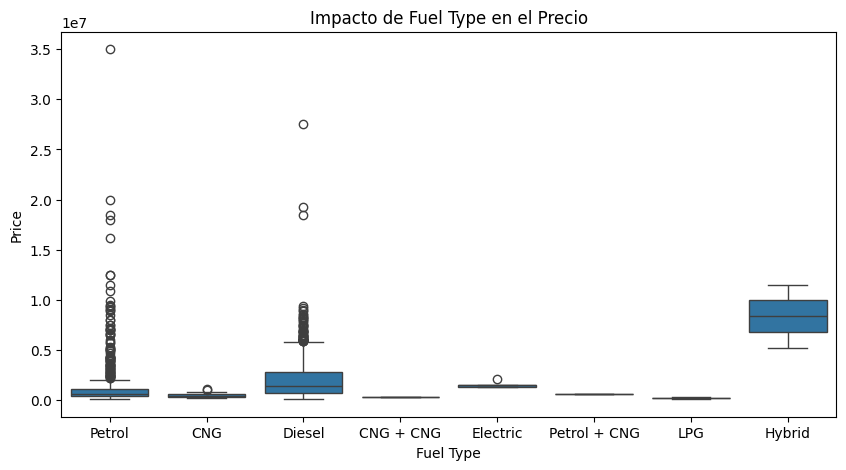

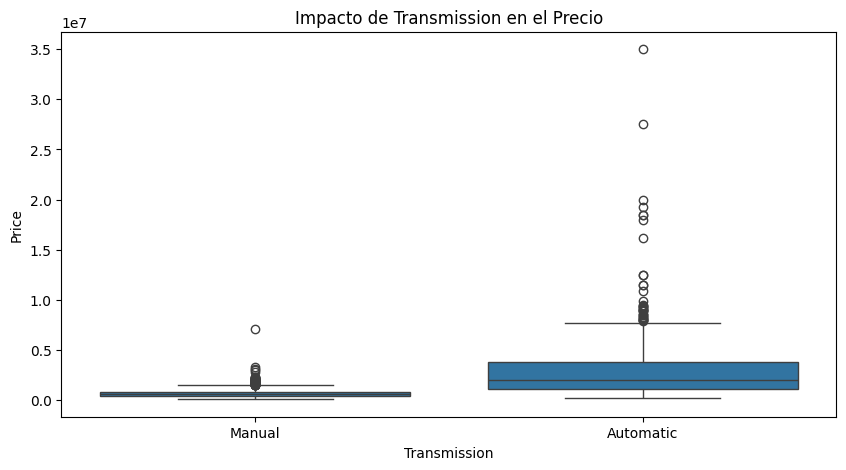

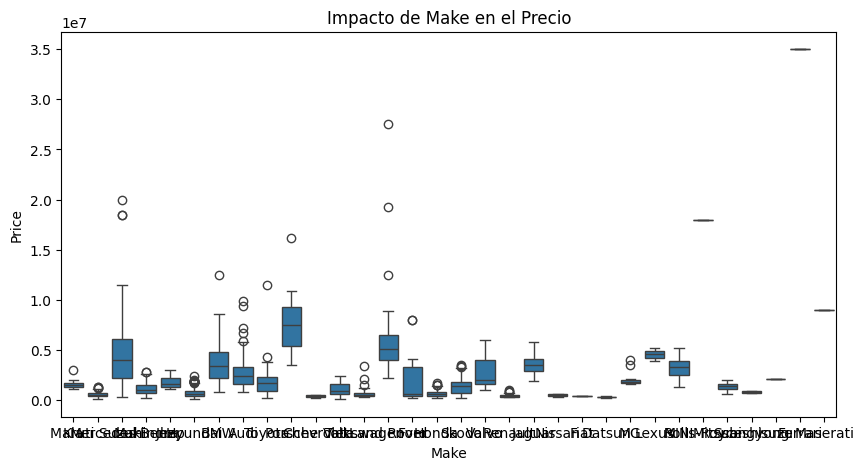

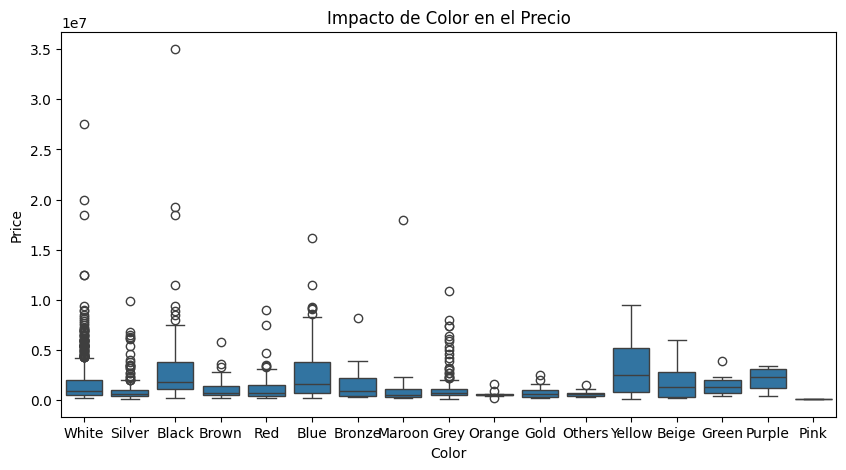

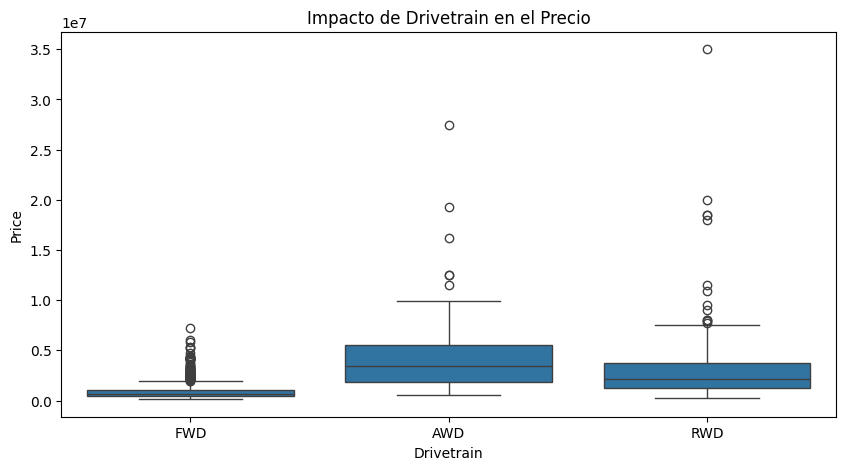

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

categorias_clave = ["Fuel Type", "Transmission", "Make", "Color", "Drivetrain"]

for categoria in categorias_clave:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=cars_aed, x=categoria, y="Price")
    plt.title(f"Impacto de {categoria} en el Precio")
    plt.show()

Todas las variables parecen ser influyentes. Los boxplots revelan la varianza entre las distintas subcategorías. Por otro lado, se ven outliers.